Device: cpu
Epoch 1/5 | Train Loss: 0.1896, Train Acc: 0.9299 | Val Loss: 0.1004, Val Acc: 0.9652
Epoch 2/5 | Train Loss: 0.0823, Train Acc: 0.9755 | Val Loss: 0.0764, Val Acc: 0.9776
Epoch 3/5 | Train Loss: 0.0584, Train Acc: 0.9833 | Val Loss: 0.0624, Val Acc: 0.9817
Epoch 4/5 | Train Loss: 0.0460, Train Acc: 0.9867 | Val Loss: 0.0512, Val Acc: 0.9868
Epoch 5/5 | Train Loss: 0.0392, Train Acc: 0.9886 | Val Loss: 0.0433, Val Acc: 0.9882


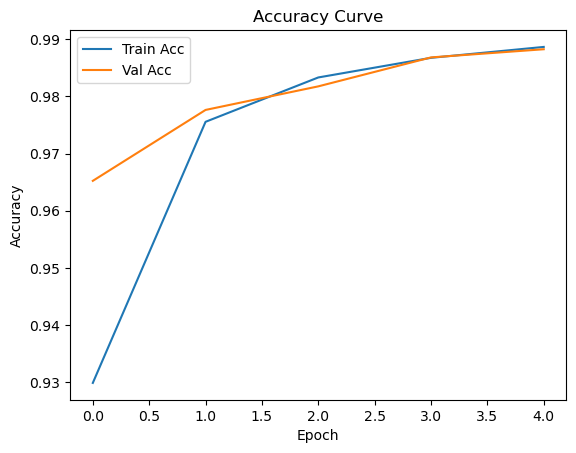

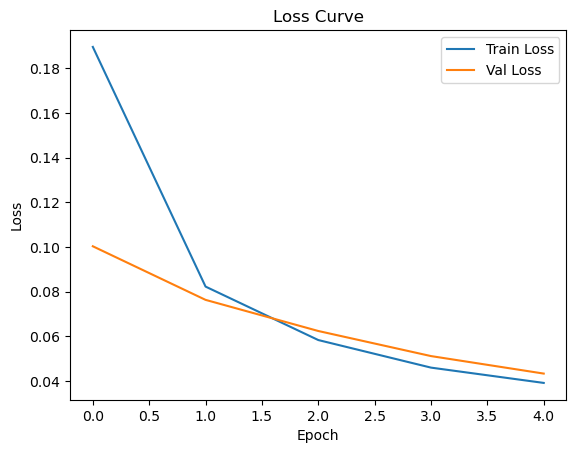

Test Accuracy: 0.9882436996622499
Precision: 0.9869
Recall:    0.9881
F1-score:  0.9875


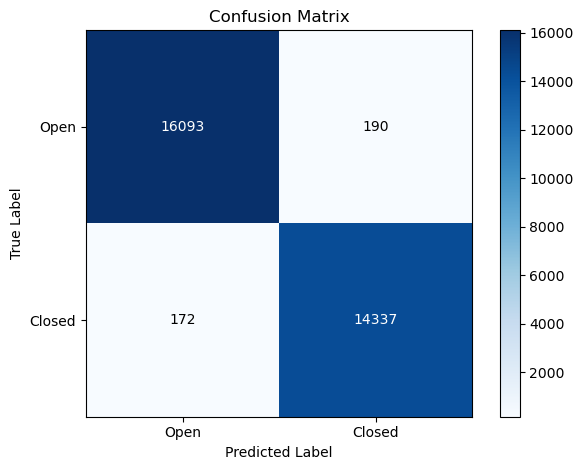

ROC AUC: 0.9982964595981647


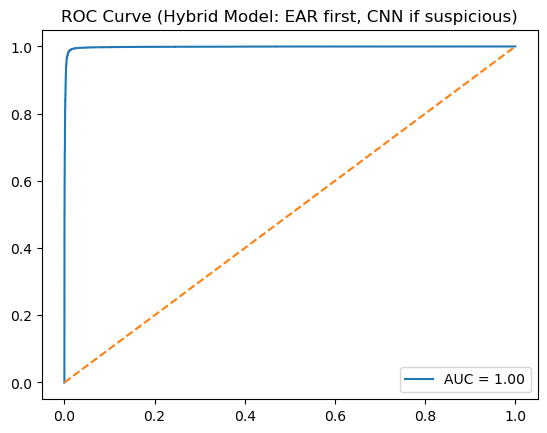

In [1]:
# =========================================================
# IMPORTS
# =========================================================
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import dlib
from scipy.spatial import distance as dist
from PIL import Image

# =========================================================
# DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================================================
# DATASET
# =========================================================
class EyeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.images, self.labels = [], []
        self.transform = transform
        for label, cls in enumerate(["open", "close"]):
            path = os.path.join(root_dir, cls)
            for img in os.listdir(path):
                if img.lower().endswith((".jpg", ".png", ".jpeg")):
                    self.images.append(os.path.join(path, img))
                    self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = cv2.imread(self.images[idx], 0)
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# =========================================================
# MODEL
# =========================================================
class EyeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 16, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 2)
        )
    def forward(self, x):
        return self.model(x)

# =========================================================
# TRANSFORM
# =========================================================
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# =========================================================
# EAR SETUP
# =========================================================
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

def eye_aspect_ratio(eye):
    A = dist.euclidean(eye[1], eye[5])
    B = dist.euclidean(eye[2], eye[4])
    C = dist.euclidean(eye[0], eye[3])
    return (A + B) / (2.0 * C)

def compute_ear(gray):
    faces = detector(gray, 0)
    if len(faces) == 0:
        return None
    shape = predictor(gray, faces[0])
    pts = np.array([[p.x, p.y] for p in shape.parts()])
    left = eye_aspect_ratio(pts[42:48])
    right = eye_aspect_ratio(pts[36:42])
    return (left + right) / 2.0

LOW_EAR = 0.20
HIGH_EAR = 0.30

# =========================================================
# DATA
# =========================================================
DATASET_PATH = "C:/Users/Lenovo/Desktop/Image/Image"
dataset = EyeDataset(DATASET_PATH, transform=transform)

# Split dataset into train/test (80/20)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# =========================================================
# TRAINING
# =========================================================
model = EyeCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(5):
    model.train()
    train_loss, correct, total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    train_loss /= len(train_loader)
    train_acc = correct / total

    # Validation
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_loss /= len(test_loader)
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/5 | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# Plot curves
plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# =========================================================
# TESTING (EAR first, CNN if suspicious)
# =========================================================
model.eval()
y_true, y_pred, y_score = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        for i in range(len(imgs)):
            img = imgs[i].cpu().numpy().squeeze()
            img = (img * 255).astype(np.uint8)
            ear = compute_ear(img)
            if ear is not None:
                if ear < LOW_EAR:
                    final_pred, final_score = 1, 1.0   # closed
                elif ear > HIGH_EAR:
                    final_pred, final_score = 0, 0.0   # open
                else:
                    cnn_pred = torch.argmax(outputs[i]).item()
                    final_pred = cnn_pred
                    final_score = probs[i][1].item()   # prob of closed
            else:
                cnn_pred = torch.argmax(outputs[i]).item()
                final_pred = cnn_pred
                final_score = probs[i][1].item()       # prob of closed
            y_true.append(labels[i].item())
            y_pred.append(final_pred)
            y_score.append(final_score)

# Accuracy
acc = accuracy_score(y_true, y_pred)
print("Test Accuracy:", acc)

# Precision, Recall, F1
precision = precision_score(y_true, y_pred, average="binary")
recall = recall_score(y_true, y_pred, average="binary")
f1 = f1_score(y_true, y_pred, average="binary")

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
classes = ["Open", "Closed"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)
print("ROC AUC:", roc_auc)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],"--")
plt.legend()
plt.title("ROC Curve (Hybrid Model: EAR first, CNN if suspicious)")
plt.show()
